In [ ]:
%%capture
!pip install pandas matplotlib numpy openpyxl -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

In [ ]:
print('Статический парсинг файла Росстата')
print('─' * 83)

df = pd.read_excel('/content/nedel_sred_cen.xlsx',
                   sheet_name='2026',
                   header=3)

name_col = df.iloc[:, 0]
date_cols = df.columns[1:]
print(f'Период: {date_cols[0]} — {date_cols[-1]}')
print(f'Недель в файле: {len(date_cols)}')

def get_price_series(keywords):
    for idx, name in name_col.items():
        if not isinstance(name, str):
            continue
        if all(kw.lower() in name.lower() for kw in keywords):
            series = pd.to_numeric(df.loc[idx].iloc[1:], errors='coerce').dropna()
            return name, series
    return None, None

# Только то, что есть в Росстате (усредненные товары, которые будут входить в нашу тарелку)
SEARCH_MAP = {
    'Куриное филе':       ['кур'],
    'Яйца куриные':       ['яйц'],
    'Огурцы свежие':      ['огурц'],
    'Помидоры свежие':    ['помидор'],
    'Масло подсолнечное': ['масло подсолнечн'],
}

found_prices = {}
found_series = {}

print('\nНайденные позиции:')
for ing_name, kws in SEARCH_MAP.items():
    rosstat_name, series = get_price_series(kws)
    if series is not None and len(series) > 0:
        last_price = series.iloc[-1]
        found_prices[ing_name] = {
            'rosstat_name': rosstat_name,
            'price_kg':     round(last_price, 2),
            'price_100g':   round(last_price / 10, 2),
        }
        found_series[ing_name] = series
        print(f' {ing_name:<25} | {rosstat_name:<40} | {last_price:.2f} ₽/кг')
    else:
        print(f' {ing_name} — не найдено')

Статический парсинг файла Росстата
───────────────────────────────────────────────────────────────────────────────────
Период: на 12 января — на 12 мая
Недель в файле: 18

Найденные позиции:
 Куриное филе              | Куры охлажденные и мороженые, кг         | 229.24 ₽/кг
 Яйца куриные              | Яйца куриные, 10 шт.                     | 111.23 ₽/кг
 Огурцы свежие             | Огурцы свежие, кг                        | 151.84 ₽/кг
 Помидоры свежие           | Помидоры свежие, кг                      | 252.02 ₽/кг
 Масло подсолнечное        | Масло подсолнечное, л                    | 153.54 ₽/кг


In [ ]:
# Тут только ингредиенты из Росстата с весами в тарелке 350г
INGREDIENTS = {
    'Куриное филе':       130,
    'Яйца куриные':       55,
    'Огурцы свежие':      65,
    'Помидоры свежие':    90,
    'Масло подсолнечное':  10,
}

rows = []
for name, grams in INGREDIENTS.items():
    if name not in found_prices:
        continue
    p100 = found_prices[name]['price_100g']
    cost = round(p100 * grams / 100, 2)
    rows.append({
        'Ингредиент':          name,
        'Граммов в тарелке':   grams,
        'Цена ₽/100г':         p100,
        'Стоимость в тарелке': cost,
        'Источник':            'Росстат 2026',
    })

df_plate = pd.DataFrame(rows)
total = df_plate['Стоимость в тарелке'].sum()
total_grams = df_plate['Граммов в тарелке'].sum()

print('Себестоимость тарелки (только данные Росстата):')
print('─' * 65)
print(f'{"Ингредиент":<25} {"Граммов":>8} {"₽/100г":>10} {"₽ в тарелке":>13}')
print('─' * 65)
for _, row in df_plate.iterrows():
    print(f'{row["Ингредиент"]:<25} {row["Граммов в тарелке"]:>8} '
          f'{row["Цена ₽/100г"]:>10.2f} {row["Стоимость в тарелке"]:>13.2f}')
print('─' * 65)
print(f'{"Итого":<25} {total_grams:>8} {"":>10} {total:>13.2f} ₽')
print(f'\nСебестоимость {total_grams}г из Росстата: {total:.2f} ₽')
print(f'В пересчёте на 100г: {total/total_grams*100:.2f} ₽')

df_plate.to_csv('/content/rosstat_prices.csv', index=False)
print('Данные Росстата сохранены в rosstat_prices.csv')

Себестоимость тарелки (только данные Росстата):
─────────────────────────────────────────────────────────────────
Ингредиент                 Граммов     ₽/100г   ₽ в тарелке
─────────────────────────────────────────────────────────────────
Куриное филе                   130      22.92         29.80
Яйца куриные                    55      11.12          6.12
Огурцы свежие                   65      15.18          9.87
Помидоры свежие                 90      25.20         22.68
Масло подсолнечное              10      15.35          1.54
─────────────────────────────────────────────────────────────────
Итого                          350                    70.01 ₽

Себестоимость 350г из Росстата: 70.01 ₽
В пересчёте на 100г: 20.00 ₽
Данные Росстата сохранены в rosstat_prices.csv


/tmp/ipykernel_5364/845716357.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plate['Ингредиент'], rotation=20, ha='right', fontsize=10)


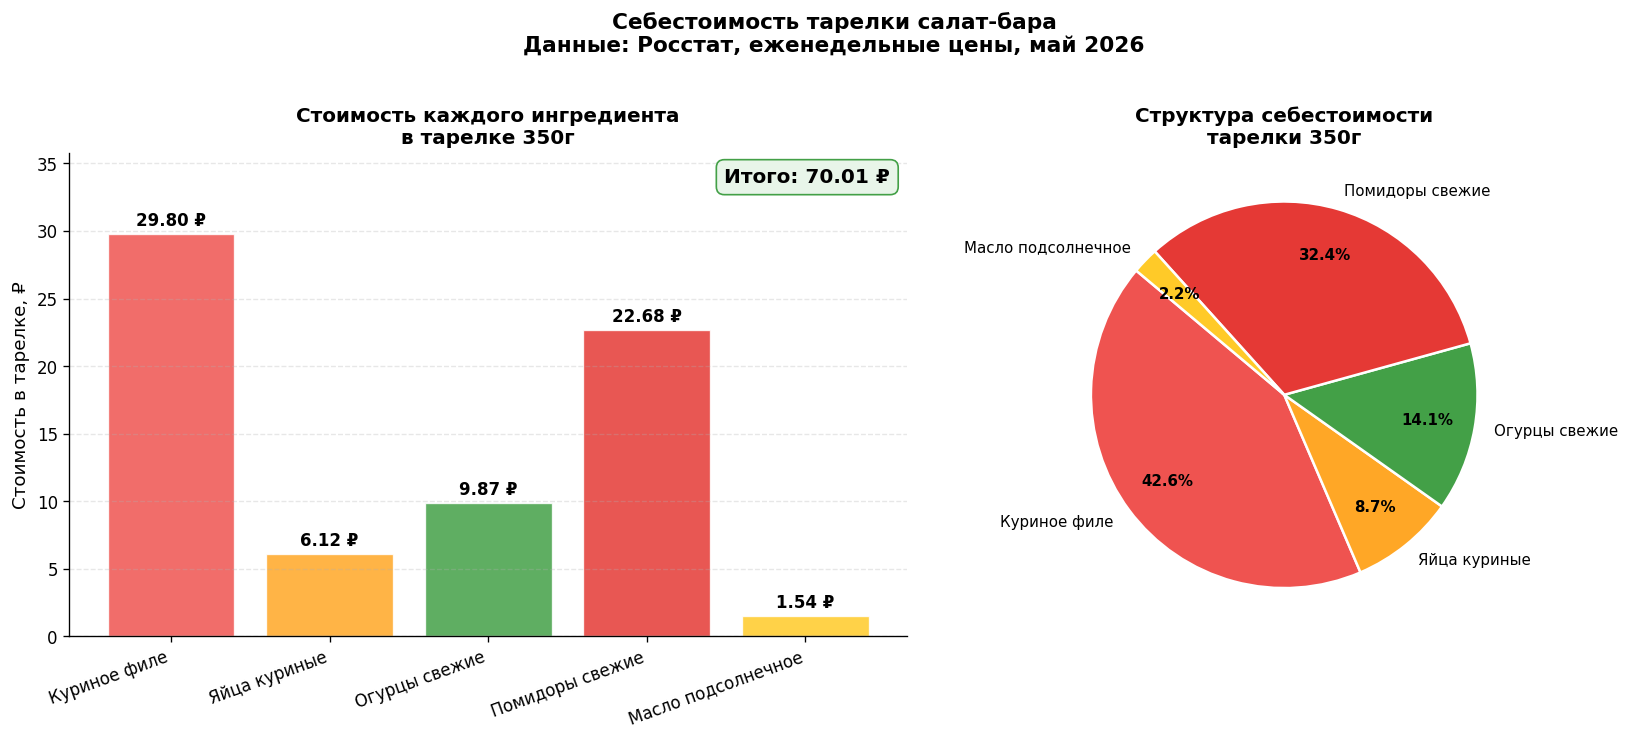

График 1 сохранён


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1.5, 1]})

colors = ['#EF5350', '#FFA726', '#43A047', '#E53935', '#FFCA28']

# Столбчатая диаграмма
bars = ax1.bar(df_plate['Ингредиент'],
               df_plate['Стоимость в тарелке'],
               color=colors[:len(df_plate)],
               alpha=0.85, edgecolor='white', linewidth=0.8)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
             f'{h:.2f} ₽', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax1.set_ylabel('Стоимость в тарелке, ₽', fontsize=11)
ax1.set_title('Стоимость каждого ингредиента\nв тарелке 350г',
              fontsize=12, fontweight='bold')
ax1.set_xticklabels(df_plate['Ингредиент'], rotation=20, ha='right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(0, df_plate['Стоимость в тарелке'].max() * 1.2)

# Текст с итогом
ax1.text(0.98, 0.97, f'Итого: {total:.2f} ₽',
         transform=ax1.transAxes, ha='right', va='top',
         fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#43A047'))

# Круговая диаграмма
wedges, texts, autotexts = ax2.pie(
    df_plate['Стоимость в тарелке'],
    labels=df_plate['Ингредиент'],
    colors=colors[:len(df_plate)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
for t in texts:
    t.set_fontsize(9)

ax2.set_title('Структура себестоимости\nтарелки 350г',
              fontsize=12, fontweight='bold')

fig.suptitle('Себестоимость тарелки салат-бара\nДанные: Росстат, еженедельные цены, май 2026',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart1_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 1 сохранён')

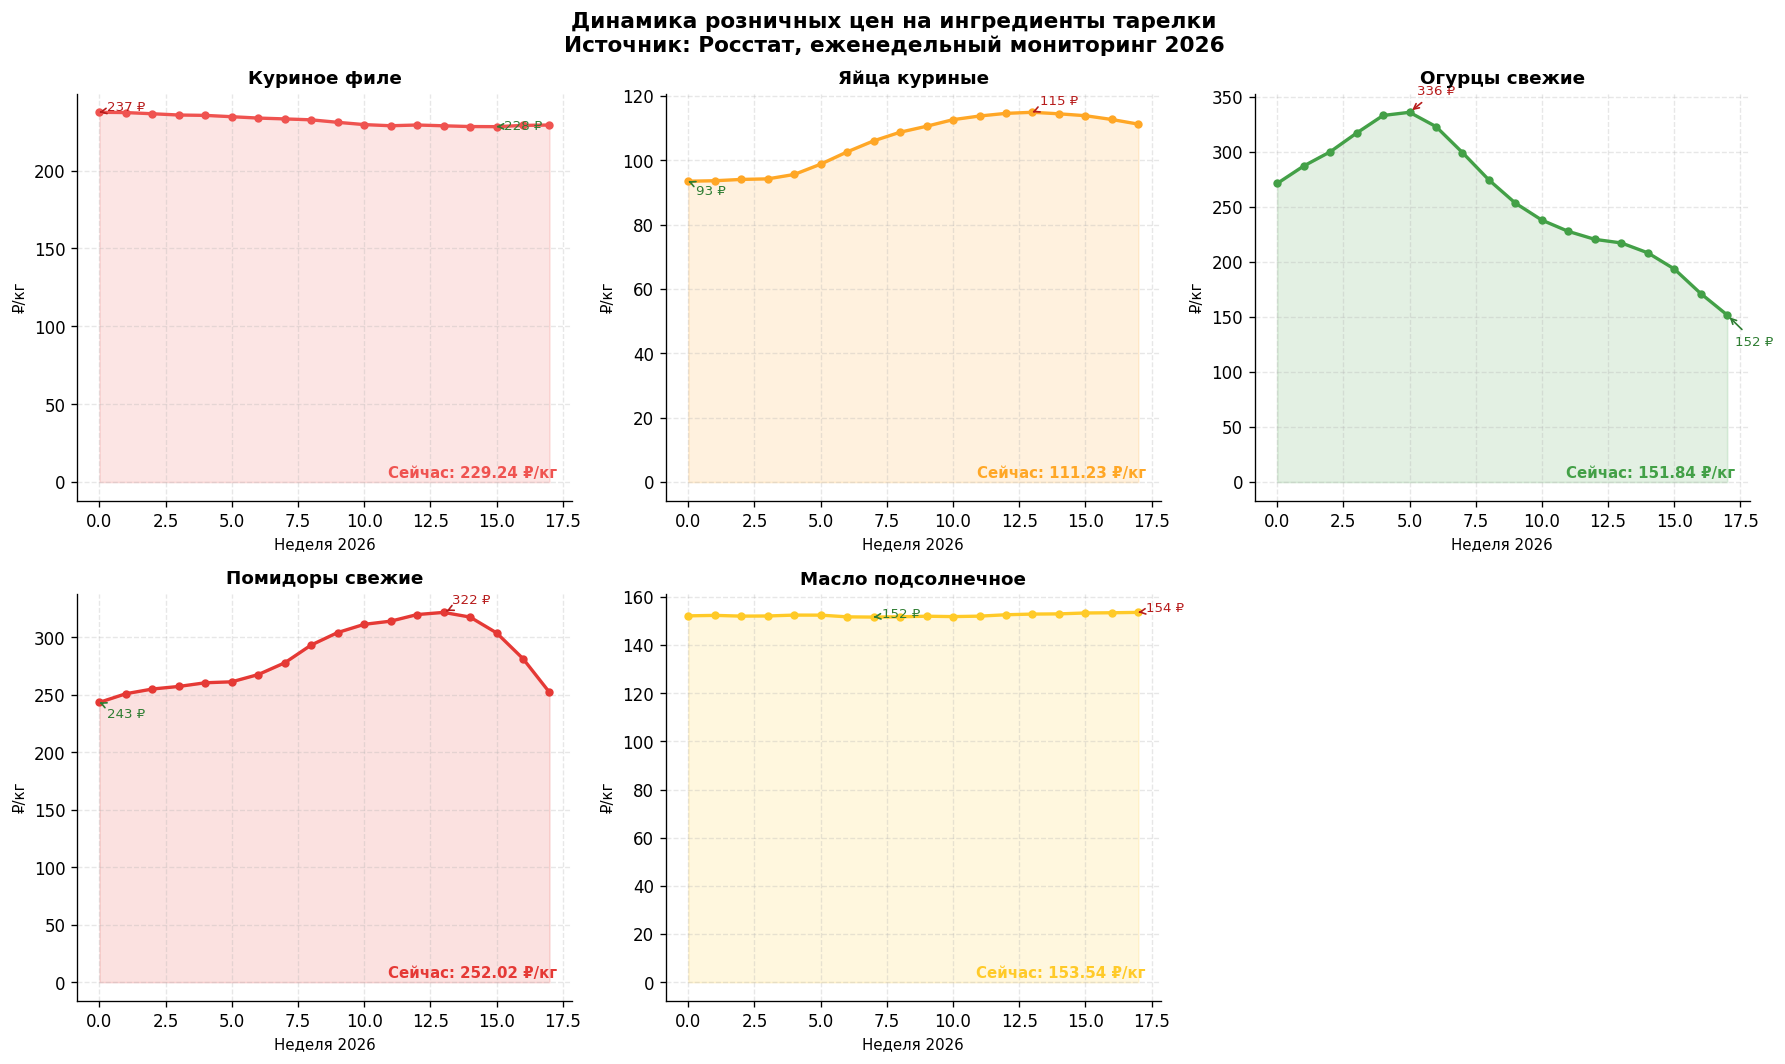

График 2 сохранён


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_colors = {
    'Куриное филе':       '#EF5350',
    'Яйца куриные':       '#FFA726',
    'Огурцы свежие':      '#43A047',
    'Помидоры свежие':    '#E53935',
    'Масло подсолнечное': '#FFCA28',
}

for i, (ing_name, series) in enumerate(found_series.items()):
    ax = axes[i]
    color = plot_colors.get(ing_name, '#999')
    weeks = list(range(len(series)))
    values = series.values

    ax.plot(weeks, values, 'o-', color=color, lw=2, ms=4)
    ax.fill_between(weeks, values, alpha=0.15, color=color)

    # Мин и макс
    mn_i = int(np.argmin(values))
    mx_i = int(np.argmax(values))
    ax.annotate(f'{values[mn_i]:.0f} ₽',
                xy=(mn_i, values[mn_i]),
                xytext=(mn_i+0.3, values[mn_i]-values.std()*0.5),
                fontsize=8, color='#2E7D32',
                arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1))
    ax.annotate(f'{values[mx_i]:.0f} ₽',
                xy=(mx_i, values[mx_i]),
                xytext=(mx_i+0.3, values[mx_i]+values.std()*0.3),
                fontsize=8, color='#B71C1C',
                arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1))

    ax.set_title(ing_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Неделя 2026', fontsize=9)
    ax.set_ylabel('₽/кг', fontsize=9)
    ax.grid(alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Подпись последней цены
    ax.text(0.97, 0.05, f'Сейчас: {values[-1]:.2f} ₽/кг',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color=color, fontweight='bold')

# Скрываем пустой 6-й subplot
axes[5].set_visible(False)

fig.suptitle('Динамика розничных цен на ингредиенты тарелки\n'
             'Источник: Росстат, еженедельный мониторинг 2026',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 2 сохранён')

In [ ]:
import subprocess, urllib.request, json, os

os.system('wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb')
os.system('apt-get install -y ./google-chrome-stable_current_amd64.deb -q 2>/dev/null')
os.system('pip install selenium selenium-stealth -q')

major = subprocess.check_output(['google-chrome','--version']).decode().split()[2].split('.')[0]
url = 'https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json'
with urllib.request.urlopen(url) as r:
    data = json.loads(r.read())

versions = [v for v in data['versions'] if v['version'].startswith(major + '.')]
latest = versions[-1]
driver_url = next(d['url'] for d in latest['downloads']['chromedriver'] if d['platform'] == 'linux64')
urllib.request.urlretrieve(driver_url, '/tmp/chromedriver.zip')
subprocess.run(['unzip', '-o', '/tmp/chromedriver.zip', '-d', '/tmp/cd'], capture_output=True)
result = subprocess.run(['find', '/tmp/cd', '-name', 'chromedriver', '-type', 'f'], capture_output=True, text=True)
subprocess.run(['cp', result.stdout.strip().split('\n')[0], '/usr/local/bin/chromedriver'])
subprocess.run(['chmod', '+x', '/usr/local/bin/chromedriver'])
print('Готово к работе')

Готово к работе


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium_stealth import stealth
import time

def create_driver():
    options = Options()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-gpu')
    options.add_argument('--ignore-certificate-errors')
    options.binary_location = '/usr/bin/google-chrome'
    service = Service(executable_path='/usr/local/bin/chromedriver')
    driver = webdriver.Chrome(service=service, options=options)
    stealth(driver,
        languages=['ru-RU', 'ru'],
        vendor='Google Inc.',
        platform='Win32',
        webgl_vendor='Intel Inc.',
        renderer='Intel Iris OpenGL Engine',
        fix_hairline=True,
    )
    return driver

driver = create_driver()
driver.get('https://www.avito.ru/moskva?q=огурцы+овощи')
time.sleep(7)
print(f'Title: {driver.title}')
body = driver.find_element(By.TAG_NAME, 'body').text
blocked = any(w in body[:300].lower() for w in
              ['403', 'forbidden', 'captcha', 'ограничен', 'vpn', 'бот'])
print(f'Статус: {"заблокирован" if blocked else "открылся!"}')
print(f'Первые 500 символов:\n{body[:500]}')
driver.quit()

Title: огурцы овощи - Купить продукты питания 🍱 в Москве | Недорогие продукты | Авито
Статус: открылся!
Первые 500 символов:
Как дальше пользоваться Авито на iOS.
Подробнее
Для бизнеса 
Карьера в Авито
Помощь
Ещё 
Избранное
Корзина
Вход и регистрация
Разместить объявление
Найти
Москва, район, метро
ГлавнаяДля дома и дачиПродукты питанияогурцы овощи
«Огурцы овощи»: объявления для Москвы65
 Сортировка 
Сначала из Москвы
Уведомлять о новых

Овощи, фрукты и Бакалея кафе, ресторан, ст
18 ₽
Москва
Новый Ассортимент. Пирожные макарони от 46р. ШТ. Доставка Бесплатно. Заказ от 5000р рублей. Доставка Москва и область 24/7. Дост


In [ ]:
import re
import time

driver = create_driver()
driver.get('https://www.avito.ru/moskva?q=огурцы+овощи')
time.sleep(7)

print('Элементы с ценами')
all_els = driver.find_elements(By.XPATH, '//*[string-length(normalize-space(text())) > 0]')
found = 0
for el in all_els:
    txt = el.text.strip()
    cls = el.get_attribute('class') or ''
    if re.search(r'\b\d{2,5}\s*[₽р]', txt) and len(txt) < 50:
        print(f'  <{el.tag_name} class="{cls[:60]}">{txt}')
        found += 1
        if found > 20:
            break

driver.quit()
driver = create_driver()
driver.get('https://www.avito.ru/moskva?q=огурцы+овощи')
time.sleep(7)

# Смотрим структуру карточек
print('Элементы с ценами')
all_els = driver.find_elements(By.XPATH, '//*[string-length(normalize-space(text())) > 0]')
found = 0
for el in all_els:
    txt = el.text.strip()
    cls = el.get_attribute('class') or ''
    if re.search(r'\b\d{2,5}\s*[₽р]', txt) and len(txt) < 50:
        print(f'  <{el.tag_name} class="{cls[:60]}">{txt}')
        found += 1
        if found > 20:
            break

driver.quit()

Элементы с ценами
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">18 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">3 600 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">35 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">300 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">240 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">300 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">217 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">100 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">260 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">150 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">100 ₽
  <span class="styles-module-size_l-kPWfk styles-module-size_l_dense-kvYNM">200 

In [ ]:
import re, time, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium_stealth import stealth

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120


class AvitoParser:
    """
    Динамический парсинг цен на продукты с Авито (Москва).
    Список ингредиентов совпадает с данными Росстата —
    для корректного сравнения двух источников.
    """

    BASE_URL = 'https://www.avito.ru/moskva?q={query}'
    PRICE_CLASS = 'styles-module-size_l-kPWfk'

    # Те же 5 позиций что и в Росстате
    INGREDIENTS = [
        {'name': 'Куриное филе',      'query': 'филе+куриное+мясо',  'grams': 130},
        {'name': 'Яйца куриные',      'query': 'яйца+куриные',       'grams': 55},
        {'name': 'Огурцы свежие',     'query': 'огурцы+свежие',      'grams': 65},
        {'name': 'Помидоры свежие',   'query': 'помидоры+свежие',    'grams': 90},
        {'name': 'Масло подсолнечное','query': 'масло+подсолнечное', 'grams': 10},
    ]

    def __init__(self):
        self.driver  = None
        self.results = []
        self.df      = None

    def _create_driver(self):
        options = Options()
        options.add_argument('--headless')
        options.add_argument('--no-sandbox')
        options.add_argument('--disable-dev-shm-usage')
        options.add_argument('--disable-gpu')
        options.add_argument('--window-size=1920,1080')
        options.add_argument('--ignore-certificate-errors')
        options.binary_location = '/usr/bin/google-chrome'
        service = Service(executable_path='/usr/local/bin/chromedriver')
        driver = webdriver.Chrome(service=service, options=options)
        stealth(driver,
            languages=['ru-RU', 'ru'],
            vendor='Google Inc.',
            platform='Win32',
            webgl_vendor='Intel Inc.',
            renderer='Intel Iris OpenGL Engine',
            fix_hairline=True,
        )
        return driver

    def start(self):
        self.driver = self._create_driver()
        print('Браузер запущен')
        return self

    def stop(self):
        if self.driver:
            self.driver.quit()
            print('Браузер закрыт')
        return self

    def _parse_prices(self, query):
        url = self.BASE_URL.format(query=query)
        self.driver.get(url)
        time.sleep(random.uniform(5, 7))

        price_elements = self.driver.find_elements(
            By.CSS_SELECTOR, f'[class*="{self.PRICE_CLASS}"]'
        )
        prices = []
        for el in price_elements:
            txt = el.text.strip().replace(' ', '')
            nums = re.findall(r'\d+', txt)
            if nums:
                price = int(nums[0])
                if 10 <= price <= 5000:
                    prices.append(price)
        return prices

    def parse_all(self):
        print('\n Парсим Авито (Москва)')
        print('─' * 80)
        for ing in self.INGREDIENTS:
            print(f'{ing["name"]:<25}', end=' ', flush=True)
            prices = self._parse_prices(ing['query'])

            if prices:
                median = float(np.median(prices))
                self.results.append({
                    'Ингредиент':          ing['name'],
                    'Граммов в тарелке':   ing['grams'],
                    'Мин. цена (₽/кг)':    float(min(prices)),
                    'Медиана (₽/кг)':      median,
                    'Макс. цена (₽/кг)':   float(max(prices)),
                    'Цена ₽/100г':         round(median / 10, 2),
                    'Стоимость в тарелке': round(median / 10 * ing['grams'] / 100, 2),
                    'Кол-во объявлений':   len(prices),
                })
                print(f' медиана {median:.0f} ₽/кг  '
                      f'(мин {min(prices)} — макс {max(prices)})  '
                      f'[{len(prices)} объявлений]')
            else:
                print('не найдено')

            time.sleep(random.uniform(3, 5))

        self.df = pd.DataFrame(self.results)
        self.df.to_csv('/content/avito_prices.csv', index=False)
        print('Данные Авито сохранены в avito_prices.csv')
        return self

    def print_table(self):
        total   = self.df['Стоимость в тарелке'].sum()
        total_g = self.df['Граммов в тарелке'].sum()

        print(f'\n Результаты парсинга Авито (Москва):')
        print('─' * 70)
        print(f'{"Ингредиент":<22} {"г":>4} {"Мин":>6} '
              f'{"Медиана":>8} {"Макс":>6} {"₽/100г":>8} {"В тарелке":>10}')
        print('─' * 70)
        for _, row in self.df.iterrows():
            print(f'{row["Ингредиент"]:<22} '
                  f'{row["Граммов в тарелке"]:>4} '
                  f'{row["Мин. цена (₽/кг)"]:>6.0f} '
                  f'{row["Медиана (₽/кг)"]:>8.0f} '
                  f'{row["Макс. цена (₽/кг)"]:>6.0f} '
                  f'{row["Цена ₽/100г"]:>8.2f} '
                  f'{row["Стоимость в тарелке"]:>10.2f}')
        print('─' * 70)
        print(f'{"ИТОГО":<22} {total_g:>4} {"":>28} {total:>10.2f} ₽')
        print(f'\n Себестоимость {total_g}г (Авито): {total:.2f} ₽')
        return self

Сравнение: Росстат vs Авито
─────────────────────────────────────────────────────────────────────
Ингредиент                г  Росстат ₽/100г  Авито ₽/100г    Разница
─────────────────────────────────────────────────────────────────────
Куриное филе            130           22.92         30.00    +30.9%
Яйца куриные             55           11.12         15.00    +34.9%
Огурцы свежие            65           15.18         20.00    +31.8%
Помидоры свежие          90           25.20         16.00    -36.5%
Масло подсолнечное       10           15.35         15.50     +1.0%
─────────────────────────────────────────────────────────────────────

Себестоимость 350г (Росстат): 70.01 ₽
Себестоимость 350г (Авито):   76.20 ₽
Разница: +6.19 ₽  (+8.8%)


/tmp/ipykernel_5364/309486866.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(df_cmp['Ингредиент'], rotation=15, ha='right', fontsize=10)


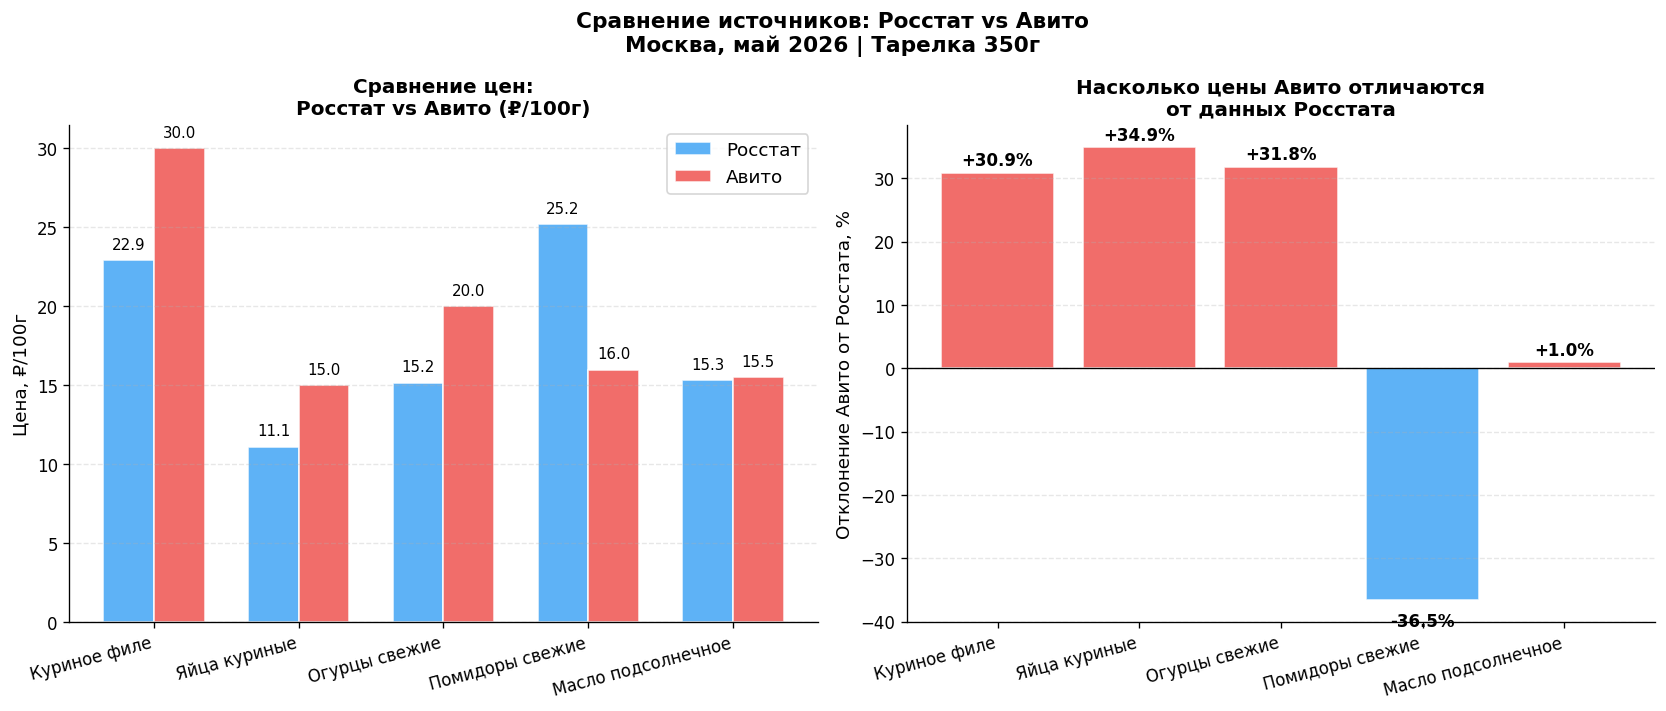

График сравнения сохранён!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Читаем оба файла
df_r = pd.read_csv('/content/rosstat_prices.csv')
df_a = pd.read_csv('/content/avito_prices.csv')

# Объединяем по названию
df_cmp = pd.merge(
    df_r[['Ингредиент', 'Граммов в тарелке', 'Цена ₽/100г', 'Стоимость в тарелке']].rename(columns={
        'Цена ₽/100г':         'Росстат ₽/100г',
        'Стоимость в тарелке': 'Росстат ₽ в тарелке',
    }),
    df_a[['Ингредиент', 'Цена ₽/100г', 'Стоимость в тарелке']].rename(columns={
        'Цена ₽/100г':         'Авито ₽/100г',
        'Стоимость в тарелке': 'Авито ₽ в тарелке',
    }),
    on='Ингредиент'
)

df_cmp['Разница (%)'] = round(
    (df_cmp['Авито ₽/100г'] - df_cmp['Росстат ₽/100г'])
    / df_cmp['Росстат ₽/100г'] * 100, 1
)

total_r = df_cmp['Росстат ₽ в тарелке'].sum()
total_a = df_cmp['Авито ₽ в тарелке'].sum()

# Таблица
print('Сравнение: Росстат vs Авито')
print('─' * 69)
print(f'{"Ингредиент":<22} {"г":>4} {"Росстат ₽/100г":>15} {"Авито ₽/100г":>13} {"Разница":>10}')
print('─' * 69)
for _, row in df_cmp.iterrows():
    sign = '' if row['Разница (%)'] > 0 else ''
    print(f'{row["Ингредиент"]:<22} {row["Граммов в тарелке"]:>4} '
          f'{row["Росстат ₽/100г"]:>15.2f} '
          f'{row["Авито ₽/100г"]:>13.2f} '
          f'  {sign}{row["Разница (%)"]:>+6.1f}%')
print('─' * 69)
print(f'\nСебестоимость 350г (Росстат): {total_r:.2f} ₽')
print(f'Себестоимость 350г (Авито):   {total_a:.2f} ₽')
print(f'Разница: {total_a - total_r:+.2f} ₽  ({(total_a-total_r)/total_r*100:+.1f}%)')

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(df_cmp))
w = 0.35

b1 = ax1.bar(x - w/2, df_cmp['Росстат ₽/100г'], w,
             label='Росстат', color='#42A5F5', alpha=0.85, edgecolor='white')
b2 = ax1.bar(x + w/2, df_cmp['Авито ₽/100г'], w,
             label='Авито', color='#EF5350', alpha=0.85, edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(df_cmp['Ингредиент'], rotation=15, ha='right', fontsize=10)
ax1.set_ylabel('Цена, ₽/100г', fontsize=11)
ax1.set_title('Сравнение цен:\nРосстат vs Авито (₽/100г)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

colors_diff = ['#EF5350' if v > 0 else '#42A5F5' for v in df_cmp['Разница (%)']]
bars3 = ax2.bar(df_cmp['Ингредиент'], df_cmp['Разница (%)'],
                color=colors_diff, alpha=0.85, edgecolor='white')
for bar in bars3:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2,
             h + (0.5 if h >= 0 else -2),
             f'{h:+.1f}%', ha='center',
             va='bottom' if h >= 0 else 'top',
             fontsize=10, fontweight='bold')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_xticklabels(df_cmp['Ингредиент'], rotation=15, ha='right', fontsize=10)
ax2.set_ylabel('Отклонение Авито от Росстата, %', fontsize=11)
ax2.set_title('Насколько цены Авито отличаются\nот данных Росстата',
              fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Сравнение источников: Росстат vs Авито\nМосква, май 2026 | Тарелка 350г',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/comparison_rosstat_avito.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сравнения сохранён!')

In [10]:
!pip install dash dash-bootstrap-components jupyter-dash -q
print('Dash установлен!')

Dash установлен!


In [11]:
import dash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go
import pandas as pd
from google.colab.output import eval_js

df_r = pd.read_csv('/content/rosstat_prices.csv')
BASE_PRICES = dict(zip(df_r['Ингредиент'], df_r['Цена ₽/100г']))
BASE_GRAMS  = dict(zip(df_r['Ингредиент'], df_r['Граммов в тарелке']))
ingredients = df_r['Ингредиент'].tolist()
colors = ['#EF5350', '#FFA726', '#43A047', '#E53935', '#FFCA28']

app = dash.Dash(__name__)

sliders = []
for i, ing in enumerate(ingredients):
    sliders.append(
        html.Div([
            html.Label(f'{ing}  ({BASE_PRICES[ing]:.1f} ₽/100г)',
                       style={'fontFamily':'Arial','fontWeight':'bold','color':'#333'}),
            dcc.Slider(id=f'slider-{i}', min=0, max=300, step=5,
                       value=BASE_GRAMS[ing],
                       marks={0:'0г',100:'100г',200:'200г',300:'300г'},
                       tooltip={'placement':'top','always_visible':True}),
        ], style={'marginBottom':'20px','padding':'15px',
                  'backgroundColor':'#f9f9f9','borderRadius':'8px',
                  'borderLeft':f'4px solid {colors[i]}'})
    )

app.layout = html.Div([
    html.H2('Себестоимость тарелки салат-бара',
            style={'textAlign':'center','fontFamily':'Arial','color':'#2E7D32'}),
    html.P('Двигай слайдеры — себестоимость пересчитывается автоматически',
           style={'textAlign':'center','color':'#666','fontFamily':'Arial'}),
    html.Div([
        html.Div(sliders,
                 style={'width':'45%','display':'inline-block',
                        'verticalAlign':'top','padding':'20px'}),
        html.Div([
            dcc.Graph(id='cost-graph'),
            html.Div(id='total-cost',
                     style={'textAlign':'center','fontSize':'20px',
                            'fontWeight':'bold','fontFamily':'Arial','color':'#2E7D32'})
        ], style={'width':'50%','display':'inline-block',
                  'verticalAlign':'top','padding':'20px'}),
    ])
])

@app.callback(
    Output('cost-graph','figure'),
    Output('total-cost','children'),
    [Input(f'slider-{i}','value') for i in range(len(ingredients))]
)
def update(*grams_values):
    costs = [round(BASE_PRICES[ing] * g / 100, 2)
             for ing, g in zip(ingredients, grams_values)]
    total       = sum(costs)
    total_grams = sum(grams_values)

    fig = go.Figure(go.Bar(
        x=ingredients, y=costs,
        marker_color=colors,
        text=[f'{c:.2f} ₽' for c in costs],
        textposition='outside',
    ))
    fig.update_layout(
        title=f'Себестоимость тарелки {total_grams}г',
        yaxis_title='Стоимость, ₽',
        plot_bgcolor='white', paper_bgcolor='white',
        font=dict(family='Arial', size=12),
        showlegend=False,
        yaxis=dict(gridcolor='#eee'),
    )

    text = (f'Итого {total_grams}г: {total:.2f} ₽  |  {total/total_grams*100:.2f} ₽/100г'
            if total_grams > 0 else 'Добавьте ингредиенты')
    return fig, text

print(eval_js("google.colab.kernel.proxyPort(8050)"))
app.run(port=8050, debug=False)

https://8050-m-s-kkb-usc1c2-20kjmz6ba8w11-c.us-central1-2.prod.colab.dev
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET /_dash-component-suites/dash/html/dash_html_components.v4_1_0m1779720554.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET /_dash-component-suites/dash/dash_table/bundle.v7_1_0m1779720554.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_1_0m1779720554.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_1_0m1779720554.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:09:30] "GET /_dash-component-suites/dash/dcc/dash_core_components-shared.v4_1_0m1779720554.j

In [ ]:
import dash
from dash import dcc, html, Input, Output
import plotly.graph_objects as go
import pandas as pd

df_r = pd.read_csv('/content/rosstat_prices.csv')
COST_350G = df_r['Стоимость в тарелке'].sum()  # себестоимость из Росстата

app2 = dash.Dash(__name__)

app2.layout = html.Div([

    html.H2('Калькулятор маржинальности салат-бара',
            style={'textAlign': 'center', 'fontFamily': 'Arial',
                   'color': '#1565C0', 'marginBottom': '5px'}),

    html.P(f'Себестоимость тарелки 350г (Росстат): {COST_350G:.2f} ₽',
           style={'textAlign': 'center', 'color': '#666',
                  'fontFamily': 'Arial', 'marginBottom': '30px',
                  'fontSize': '16px'}),

    # Слайдеры
    html.Div([

        html.Div([
            html.Label('Цена продажи тарелки, ₽',
                       style={'fontFamily': 'Arial', 'fontWeight': 'bold',
                              'fontSize': '15px'}),
            dcc.Slider(
                id='price-slider',
                min=100, max=800, step=10,
                value=390,
                marks={100: '100₽', 200: '200₽', 300: '300₽',
                       400: '400₽', 500: '500₽', 600: '600₽',
                       700: '700₽', 800: '800₽'},
                tooltip={'placement': 'top', 'always_visible': True},
            ),
        ], style={'marginBottom': '30px', 'padding': '20px',
                  'backgroundColor': '#E3F2FD', 'borderRadius': '8px',
                  'borderLeft': '4px solid #1565C0'}),

        html.Div([
            html.Label('Количество тарелок в день',
                       style={'fontFamily': 'Arial', 'fontWeight': 'bold',
                              'fontSize': '15px'}),
            dcc.Slider(
                id='plates-slider',
                min=10, max=500, step=10,
                value=200,
                marks={10: '10', 100: '100', 200: '200',
                       300: '300', 400: '400', 500: '500'},
                tooltip={'placement': 'top', 'always_visible': True},
            ),
        ], style={'marginBottom': '30px', 'padding': '20px',
                  'backgroundColor': '#E8F5E9', 'borderRadius': '8px',
                  'borderLeft': '4px solid #2E7D32'}),

        html.Div([
            html.Label('Рабочих дней в месяце',
                       style={'fontFamily': 'Arial', 'fontWeight': 'bold',
                              'fontSize': '15px'}),
            dcc.Slider(
                id='days-slider',
                min=1, max=31, step=1,
                value=26,
                marks={1: '1', 10: '10', 20: '20', 26: '26', 31: '31'},
                tooltip={'placement': 'top', 'always_visible': True},
            ),
        ], style={'marginBottom': '30px', 'padding': '20px',
                  'backgroundColor': '#FFF3E0', 'borderRadius': '8px',
                  'borderLeft': '4px solid #E65100'}),

        # Карточки с результатами
        html.Div(id='cards',
                 style={'marginTop': '20px'}),

    ], style={'width': '40%', 'display': 'inline-block',
              'verticalAlign': 'top', 'padding': '20px'}),

    # Графики
    html.Div([
        dcc.Graph(id='margin-graph'),
        dcc.Graph(id='monthly-graph'),
    ], style={'width': '56%', 'display': 'inline-block',
              'verticalAlign': 'top', 'padding': '10px'}),

], style={'maxWidth': '1300px', 'margin': '0 auto'})


@app2.callback(
    Output('margin-graph',  'figure'),
    Output('monthly-graph', 'figure'),
    Output('cards',         'children'),
    Input('price-slider',  'value'),
    Input('plates-slider', 'value'),
    Input('days-slider',   'value'),
)
def update(price, plates, days):
    profit_per   = round(price - COST_350G, 2)
    margin_pct   = round(profit_per / price * 100, 1)
    revenue_day  = round(price * plates, 2)
    cost_day     = round(COST_350G * plates, 2)
    profit_day   = round(profit_per * plates, 2)
    revenue_month= round(revenue_day * days, 2)
    cost_month   = round(cost_day * days, 2)
    profit_month = round(profit_day * days, 2)

    # График 1 — одна тарелка
    fig1 = go.Figure()
    fig1.add_trace(go.Bar(
        name='Себестоимость',
        x=['Одна тарелка'],
        y=[COST_350G],
        marker_color='#EF5350',
        text=[f'{COST_350G:.2f} ₽'],
        textposition='inside',
    ))
    fig1.add_trace(go.Bar(
        name='Прибыль',
        x=['Одна тарелка'],
        y=[profit_per],
        marker_color='#43A047',
        text=[f'{profit_per:.2f} ₽'],
        textposition='inside',
    ))
    fig1.update_layout(
        barmode='stack',
        title=f'Структура цены тарелки {price} ₽<br>Маржа: {margin_pct}%',
        yaxis_title='Рублей',
        plot_bgcolor='white', paper_bgcolor='white',
        font=dict(family='Arial', size=12),
        legend=dict(orientation='h', y=-0.2),
        height=280,
        margin=dict(t=60, b=40),
        yaxis=dict(gridcolor='#eee'),
    )

    # График 2 — месяц
    fig2 = go.Figure()
    fig2.add_trace(go.Bar(
        name='Себестоимость',
        x=['За месяц'],
        y=[cost_month],
        marker_color='#EF5350',
        text=[f'{cost_month/1000:.1f} тыс.₽'],
        textposition='inside',
    ))
    fig2.add_trace(go.Bar(
        name='Прибыль',
        x=['За месяц'],
        y=[profit_month],
        marker_color='#43A047',
        text=[f'{profit_month/1000:.1f} тыс.₽'],
        textposition='inside',
    ))
    fig2.update_layout(
        barmode='stack',
        title=f'Выручка за месяц: {revenue_month/1000:.1f} тыс.₽<br>({plates} тарелок × {days} дней)',
        yaxis_title='Рублей',
        plot_bgcolor='white', paper_bgcolor='white',
        font=dict(family='Arial', size=12),
        legend=dict(orientation='h', y=-0.2),
        height=280,
        margin=dict(t=60, b=40),
        yaxis=dict(gridcolor='#eee'),
    )

    # Карточки
    card_style = {
        'padding': '15px', 'borderRadius': '8px',
        'marginBottom': '10px', 'textAlign': 'center',
        'fontFamily': 'Arial',
    }
    cards = html.Div([
        html.Div([
            html.Div('Прибыль с тарелки',
                     style={'fontSize': '13px', 'color': '#666'}),
            html.Div(f'{profit_per:.2f} ₽',
                     style={'fontSize': '24px', 'fontWeight': 'bold',
                            'color': '#2E7D32'}),
        ], style={**card_style, 'backgroundColor': '#E8F5E9',
                  'border': '1px solid #A5D6A7'}),

        html.Div([
            html.Div('Маржинальность',
                     style={'fontSize': '13px', 'color': '#666'}),
            html.Div(f'{margin_pct}%',
                     style={'fontSize': '24px', 'fontWeight': 'bold',
                            'color': '#1565C0'}),
        ], style={**card_style, 'backgroundColor': '#E3F2FD',
                  'border': '1px solid #90CAF9'}),

        html.Div([
            html.Div('Прибыль в день',
                     style={'fontSize': '13px', 'color': '#666'}),
            html.Div(f'{profit_day/1000:.1f} тыс.₽',
                     style={'fontSize': '24px', 'fontWeight': 'bold',
                            'color': '#E65100'}),
        ], style={**card_style, 'backgroundColor': '#FFF3E0',
                  'border': '1px solid #FFCC80'}),

        html.Div([
            html.Div('Прибыль в месяц',
                     style={'fontSize': '13px', 'color': '#666'}),
            html.Div(f'{profit_month/1000:.1f} тыс.₽',
                     style={'fontSize': '24px', 'fontWeight': 'bold',
                            'color': '#6A1B9A'}),
        ], style={**card_style, 'backgroundColor': '#F3E5F5',
                  'border': '1px solid #CE93D8'}),
    ])

    return fig1, fig2, cards


from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8051)"))
app2.run(port=8051, debug=False)

https://8051-m-s-kkb-usc1c2-20kjmz6ba8w11-c.us-central1-2.prod.colab.dev
Dash is running on http://127.0.0.1:8051/



INFO:dash.dash:Dash is running on http://127.0.0.1:8051/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8051
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:08] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:09] "GET /_dash-component-suites/dash/dcc/dash_core_components-shared.v4_1_0m1779720554.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:09] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_1_0m1779720554.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:09] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_1_0m1779720554.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:09] "GET /_dash-component-suites/dash/html/dash_html_components.v4_1_0m1779720554.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [25/May/2026 17:10:09] "GET /_dash-component-suites/dash/dash_table/bundle.v7_1_0m1779720554